In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_6/XY'

def load_judgements(arm):
    path = f'{RESULTS_DIR}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms = {
    'arm_0':  'Arm 0: (None, X+Y)',
    'arm_1':  'Arm 1: (X+, X)',
    'arm_2':  'Arm 2: (Y-, X)',
    'arm_3':  'Arm 3: (X+ & Y-, X)',
    'arm_4':  'Arm 4: (X+, Y)',
    'arm_5':  'Arm 5: (Y-, Y)',
    'arm_6':  'Arm 6: (X+ & Y-, Y)',
    'arm_7':  'Arm 7: (X+, X+Y)',
    'arm_8':  'Arm 8: (Y-, X+Y)',
    'arm_9':  'Arm 9: (X+ & Y-, X+Y)',
    'arm_10': 'Arm 10: (X+, X)+(None, Y)',
    'arm_11': 'Arm 11: (Y-, X)+(None, Y)',
    'arm_12': 'Arm 12: (X+ & Y-, X)+(None, Y)',
    'arm_13': 'Arm 13: (X+, Y)+(None, X)',
    'arm_14': 'Arm 14: (Y-, Y)+(None, X)',
    'arm_15': 'Arm 15: (X+ & Y-, Y)+(None, X)',
}

all_data = {}
all_summaries = {}
for arm in arms:
    all_data[arm], all_summaries[arm] = load_judgements(arm)
    s = all_summaries[arm]
    print(f"{arms[arm]}: comma={s['mean_comma_prob']:.4f}, semi={s['mean_semicolon_prob']:.4f}")

Arm 0: (None, X+Y): comma=0.5301, semi=0.4293
Arm 1: (X+, X): comma=0.5894, semi=0.2710
Arm 2: (Y-, X): comma=0.7554, semi=0.1684
Arm 3: (X+ & Y-, X): comma=0.2735, semi=0.5882
Arm 4: (X+, Y): comma=0.0171, semi=0.9540
Arm 5: (Y-, Y): comma=0.0462, semi=0.7025
Arm 6: (X+ & Y-, Y): comma=0.0214, semi=0.8221
Arm 7: (X+, X+Y): comma=0.3509, semi=0.6332
Arm 8: (Y-, X+Y): comma=0.1596, semi=0.8145
Arm 9: (X+ & Y-, X+Y): comma=0.0331, semi=0.9356
Arm 10: (X+, X)+(None, Y): comma=0.0083, semi=0.9842
Arm 11: (Y-, X)+(None, Y): comma=0.0032, semi=0.9927
Arm 12: (X+ & Y-, X)+(None, Y): comma=0.0016, semi=0.9931
Arm 13: (X+, Y)+(None, X): comma=0.9565, semi=0.0123
Arm 14: (Y-, Y)+(None, X): comma=0.9239, semi=0.0309
Arm 15: (X+ & Y-, Y)+(None, X): comma=0.8679, semi=0.0778


/tmp/ipykernel_1837/2367288319.py:56: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(
/tmp/ipykernel_1837/2367288319.py:73: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(


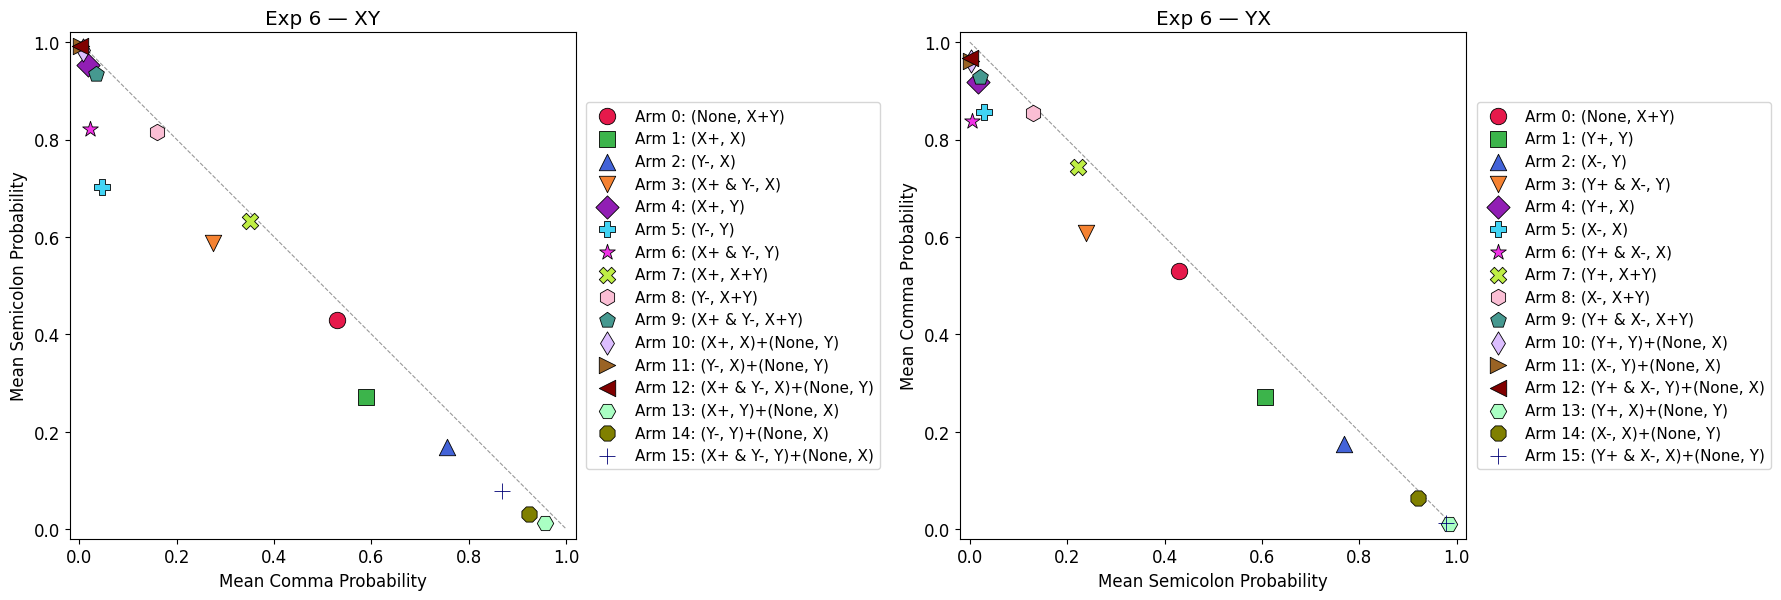

In [5]:
# Side-by-side: XY (left) and YX (right, axes swapped)
RESULTS_DIR_YX = '/workspace/spar-team-recon/projects/ip/results/exp_6/YX'

def load_judgements_dir(results_dir, arm):
    path = f'{results_dir}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms_yx = {
    'arm_0':  'Arm 0: (None, X+Y)',
    'arm_1':  'Arm 1: (Y+, Y)',
    'arm_2':  'Arm 2: (X-, Y)',
    'arm_3':  'Arm 3: (Y+ & X-, Y)',
    'arm_4':  'Arm 4: (Y+, X)',
    'arm_5':  'Arm 5: (X-, X)',
    'arm_6':  'Arm 6: (Y+ & X-, X)',
    'arm_7':  'Arm 7: (Y+, X+Y)',
    'arm_8':  'Arm 8: (X-, X+Y)',
    'arm_9':  'Arm 9: (Y+ & X-, X+Y)',
    'arm_10': 'Arm 10: (Y+, Y)+(None, X)',
    'arm_11': 'Arm 11: (X-, Y)+(None, X)',
    'arm_12': 'Arm 12: (Y+ & X-, Y)+(None, X)',
    'arm_13': 'Arm 13: (Y+, X)+(None, Y)',
    'arm_14': 'Arm 14: (X-, X)+(None, Y)',
    'arm_15': 'Arm 15: (Y+ & X-, X)+(None, Y)',
}

all_summaries_yx = {}
for arm in arms_yx:
    _, all_summaries_yx[arm] = load_judgements_dir(RESULTS_DIR_YX, arm)

# Colors and markers (same as before)
colors = [
    '#e6194B', '#3cb44b', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
    '#fabed4', '#469990', '#dcbeff', '#9A6324',
    '#800000', '#aaffc3', '#808000', '#000075',
]
markers = [
    'o', 's', '^', 'v',
    'D', 'P', '*', 'X',
    'h', 'p', 'd', '>',
    '<', 'H', '8', '+',
]

arm_keys = list(arms.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))

# Left: XY
for i, arm in enumerate(arm_keys):
    s = all_summaries[arm]
    ax1.scatter(
        s['mean_comma_prob'], s['mean_semicolon_prob'],
        color=colors[i], marker=markers[i], s=140, edgecolors='black',
        linewidths=0.6, zorder=3, label=arms[arm],
    )
ax1.plot([0, 1], [1, 0], 'k--', linewidth=0.8, alpha=0.4)
ax1.set_xlabel('Mean Comma Probability')
ax1.set_ylabel('Mean Semicolon Probability')
ax1.set_title('Exp 6 — XY')
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)
ax1.set_aspect('equal')
ax1.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

# Right: YX (axes swapped: semicolon on x, comma on y)
for i, arm in enumerate(arm_keys):
    s = all_summaries_yx[arm]
    ax2.scatter(
        s['mean_semicolon_prob'], s['mean_comma_prob'],
        color=colors[i], marker=markers[i], s=140, edgecolors='black',
        linewidths=0.6, zorder=3, label=arms_yx[arm],
    )
ax2.plot([0, 1], [1, 0], 'k--', linewidth=0.8, alpha=0.4)
ax2.set_xlabel('Mean Semicolon Probability')
ax2.set_ylabel('Mean Comma Probability')
ax2.set_title('Exp 6 — YX')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)
ax2.set_aspect('equal')
ax2.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

plt.tight_layout()
plt.show()
